In [1]:
import pandas as pd

In [7]:
import yfinance as yf
import datetime as dt

In [10]:
# Define your date range
start = dt.datetime(2021, 6, 1)
end = dt.datetime(2022, 1, 28)

# Fetch data using yfinance (Note the '.NS' suffix for NSE India stocks)
stk_data = yf.download('TATACONSUM.NS', start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [11]:
stk_data=stk_data[["Open","High","Low","Close"]]
#stk_data.to_csv("Tatacoffee13_21.csv")

In [12]:
stk_data

Price,Open,High,Low,Close
Ticker,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS,TATACONSUM.NS
Date,,,,
2021-06-01,635.153931,636.537200,626.568191,635.153931
2021-06-02,634.867785,643.692018,629.764063,642.547241
2021-06-03,644.884494,651.562292,642.261073,648.700378
2021-06-04,649.511307,658.192480,643.930598,655.330566
2021-06-07,658.240032,674.457540,655.664298,667.732056
...,...,...,...,...
2022-01-20,698.514254,715.975923,688.104443,694.100891
2022-01-21,691.750300,712.809839,683.115414,697.075134


In [13]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (166, 1)


In [14]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [15]:
orders=[(0,0,0),(0,0,1),(2,0,1),(1,1,1)]
#orderslist=[]
#rscorelist=[]
for i in orders:
    #orderslist.append(i)
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(data1, order=i, seasonal_order=(0,0,0,12))
    model_fit = model.fit()
    # make prediction
    y_pred= model_fit.predict(0, len(data1)-1)
    #print(y_pred)
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)
    

RMSE-Test: 0.6001134809848007
maPe-Testset: 0.9939759036144579
RMSE-Test: 0.31740881673203825
maPe-Testset: 0.5162160275920653
RMSE-Test: 0.051684990405568024
maPe-Testset: 0.0977610335063055
RMSE-Test: 0.05166386899245938
maPe-Testset: 0.09802910546890829


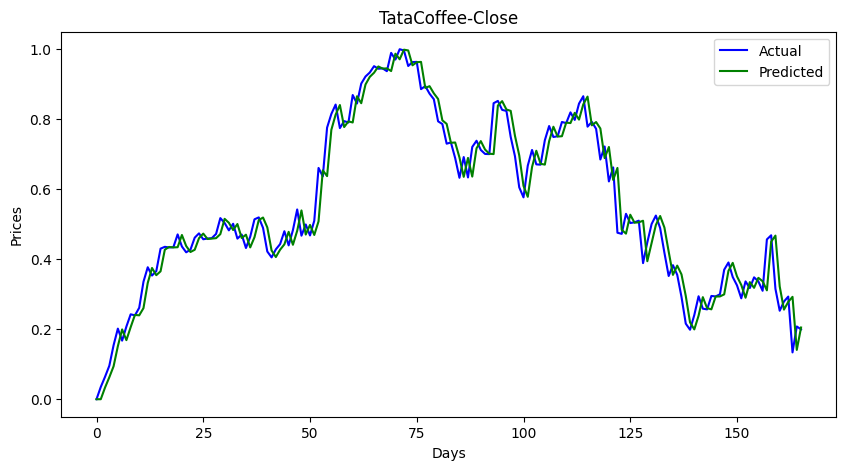

In [16]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [17]:
len(data1)

166

In [18]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [19]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

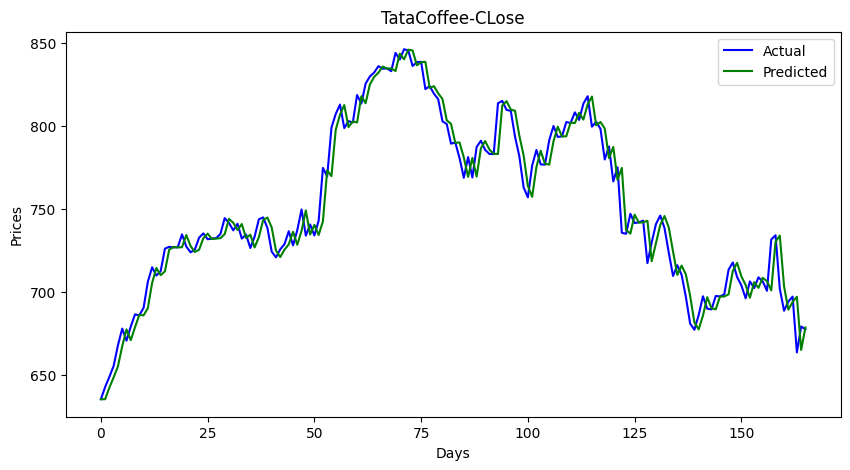

In [21]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [22]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Test: 10.909382182050425
maPe-Testset: 0.010890029245889093


In [23]:
forecast=model_fit.predict(len(data1), len(data1)+1)

In [24]:
forecast

array([0.19984173, 0.19984436])

In [25]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [26]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [27]:
forecast_stock_price_test_oriF

,Closefore
0,677.352663
1,677.353219


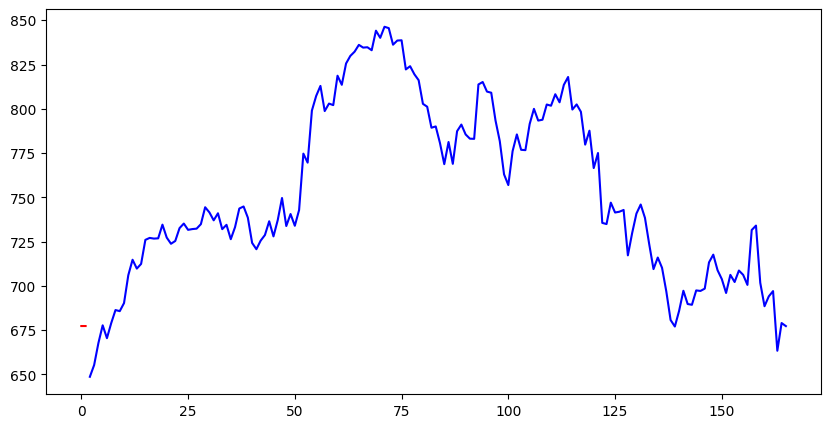

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[2:2225], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")
